In [15]:
# Cell 1: Environment Setup & Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Progress bar for loops

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [16]:
# Cell 2: Hyperparameters & Noise Scheduler
# 1. Hyperparameters for the Diffusion Process
batch_size = 128
n_steps = 1000      # Total number of diffusion timesteps (T)
beta_start = 0.0001 # Initial noise level (at t=0)
beta_end = 0.02     # Final noise level (at t=T)

# 2. Linear Noise Schedule (Beta values)
# We define how much noise is added at each step using a linear distribution
betas = torch.linspace(beta_start, beta_end, n_steps).to(device)

# 3. Derived values for Diffusion calculation (based on DDPM Paper)
# alpha represents the amount of the original image preserved at each step
alphas = 1.0 - betas

# alphas_cumprod (Alpha bar - ᾱ) is the cumulative product of alphas
# It allows us to sample any timestep 't' directly from the original image 'x_0'
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Function for the Forward Diffusion Process (q-sampling)
# This adds a specific amount of Gaussian noise to an original image (x_start)
# based on the provided timestep (t)
def q_sample(x_start, t, noise=None):
    if noise is None:
        # Generate random Gaussian noise if not provided
        noise = torch.randn_like(x_start)

    # Calculate the coefficients for the Forward Process formula:
    # q(x_t | x_0) = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise

    # Square root of cumulative alpha at timestep t
    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)

    # Square root of (1 - cumulative alpha) at timestep t
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)

    # Return the noisy image at timestep 't'
    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

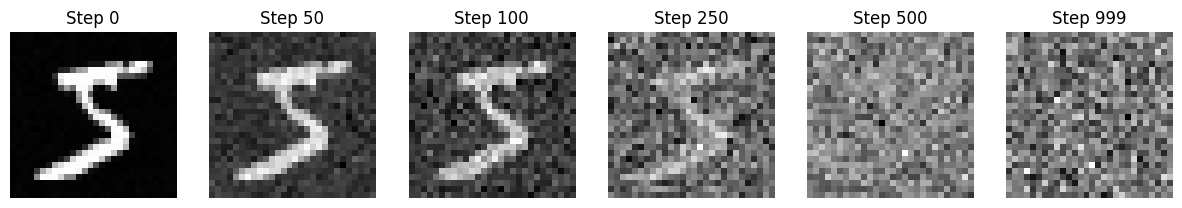

In [17]:
# Cell 3: Dataset Loading & Forward Process Visualization
# 1. Define Data Transformations
# Diffusion models perform better when data is centered around zero
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1)
])

# 2. Download and Load MNIST Dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Function to Visualize the Forward Diffusion Process
def visualize_forward_diffusion():
    # Grab a single sample image from the dataset
    image, _ = train_dataset[0]
    image = image.unsqueeze(0).to(device) # Add batch dimension

    # Select specific time steps to display the progression of noise
    steps = [0, 50, 100, 250, 500, 999]
    plt.figure(figsize=(15, 3))

    for i, t in enumerate(steps):
        t_tensor = torch.tensor([t]).to(device)
        # Generate noisy version of the image at step t
        noisy_image = q_sample(image, t_tensor)

        # Denormalize from [-1, 1] back to [0, 1] for visualization
        disp_img = (noisy_image.cpu().squeeze() + 1) / 2

        plt.subplot(1, len(steps), i + 1)
        plt.imshow(disp_img, cmap='gray')
        plt.title(f"Step {t}")
        plt.axis('off')
    plt.show()

# Execute the visualization
visualize_forward_diffusion()

In [18]:
# Cell 4: The U-Net Model Architecture
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Translates the scalar time step 't' into a vector embedding.
    This allows the model to know which diffusion stage it is currently processing.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        # Calculate frequency log-scale for embeddings
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        # Combine time step with frequencies
        embeddings = time[:, None] * embeddings[None, :]
        # Concatenate sine and cosine transformations for positional encoding
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class SimpleUNet(nn.Module):
    """
    A simplified U-Net architecture designed for MNIST (28x28 grayscale images).
    It predicts the noise added to an image at a specific time step 't'.
    """
    def __init__(self):
        super().__init__()
        image_channels = 1      # MNIST is grayscale (1 channel)
        down_channels = (32, 64, 128)
        up_channels = (128, 64, 32)
        out_channels = 1
        time_emb_dim = 32       # Dimension of the time embedding vector

        # Time embedding MLP: Processes the time step into a useful feature vector
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Encoder (Downsampling path): Extracting features and reducing spatial resolution
        self.down1 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.down2 = nn.Conv2d(down_channels[0], down_channels[1], 3, stride=2, padding=1) # 28x28 -> 14x14
        self.down3 = nn.Conv2d(down_channels[1], down_channels[2], 3, stride=2, padding=1) # 14x14 -> 7x7

        # Decoder (Upsampling path): Reconstructing the image resolution to predict noise
        self.up1 = nn.ConvTranspose2d(down_channels[2], up_channels[1], 2, stride=2)       # 7x7 -> 14x14
        self.up2 = nn.ConvTranspose2d(up_channels[1], up_channels[2], 2, stride=2)         # 14x14 -> 28x28

        # Final output layer to produce the predicted noise mask
        self.out = nn.Conv2d(up_channels[2], out_channels, 3, padding=1)

    def forward(self, x, t):
        # 1. Process time step 't' through the embedding layer
        t = self.time_mlp(t)

        # 2. Forward pass through the Encoder
        x1 = F.relu(self.down1(x))
        x2 = F.relu(self.down2(x1))
        x3 = F.relu(self.down3(x2))

        # 3. Forward pass through the Decoder
        x = F.relu(self.up1(x3))
        x = F.relu(self.up2(x))

        # 4. Final output (Predicted Noise)
        return self.out(x)

# Initialize the model and move it to the configured device
model = SimpleUNet().to(device)

# Adam optimizer for updating model weights based on the loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model Architecture Loaded!")

Model Architecture Loaded!


In [19]:
# Cell 5: The Training Loop
# Number of training iterations.
epochs = 30

# Set the model to training mode
model.train()

for epoch in range(epochs):
    # Initialize progress bar for the dataset batches
    pbar = tqdm(train_loader)
    losses = []

    for batch, _ in pbar:
        # Reset gradients from the previous iteration
        optimizer.zero_grad()

        # Move the batch of images to the GPU
        batch = batch.to(device)

        # 1. Sample random timesteps 't' for each image in the batch (0 to 999)
        t = torch.randint(0, n_steps, (batch.shape[0],), device=device).long()

        # 2. Generate target noise (Standard Gaussian Noise)
        noise = torch.randn_like(batch)

        # 3. Apply the Forward Diffusion Process (Mix image with noise)
        x_noisy = q_sample(batch, t, noise)

        # 4. Model Prediction: Predict the noise that was added to the image
        predicted_noise = model(x_noisy, t)

        # 5. Calculate Loss using Mean Squared Error (MSE)
        loss = F.mse_loss(noise, predicted_noise)

        # 6. Backpropagation: Update model weights
        loss.backward()
        optimizer.step()

        # Track and display the average loss for the current epoch
        losses.append(loss.item())
        pbar.set_description(f"Epoch {epoch+1} | Loss: {np.mean(losses):.4f}")

print("Training Complete!")

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

...

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

Training Complete!


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

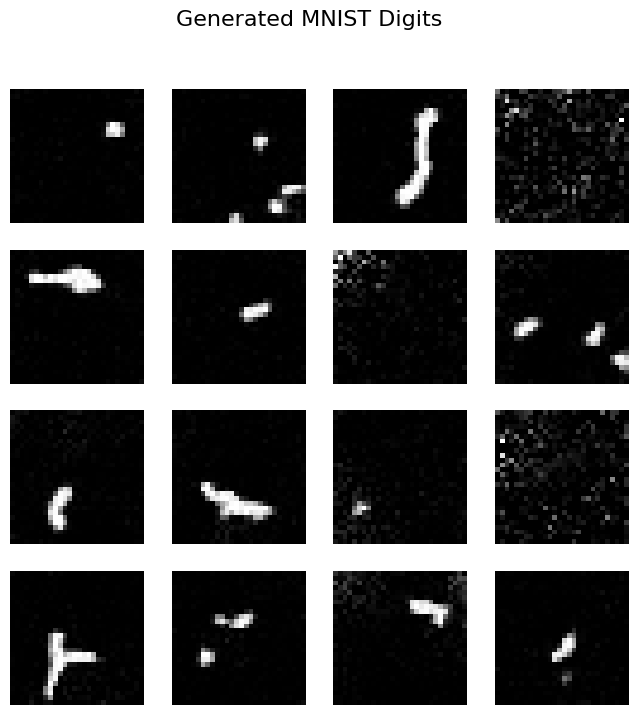

In [20]:
# Cell 6: Image Generation (Reverse Diffusion Sampling)

@torch.no_grad() # Disable gradient calculation to save memory and speed up inference
def sample_ddpm(n_samples=16):
    """
    Generates new images by reversing the diffusion process from pure noise.
    """
    model.eval() # Set model to evaluation mode

    # 1. Start with pure Gaussian noise (Standard Normal Distribution)
    # Shape: [Batch_Size, Channels, Height, Width]
    img = torch.randn((n_samples, 1, 28, 28), device=device)

    # 2. Iterate backwards from T-1 down to 0
    for i in tqdm(reversed(range(n_steps)), total=n_steps, desc="Sampling"):
        # Create a batch of current timesteps
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)

        # 3. Model predicts the noise present in the current image
        predicted_noise = model(img, t)

        # Get scheduler variables for the current step i
        beta_t = betas[i]
        alpha_t = alphas[i]
        alpha_cumprod_t = alphas_cumprod[i]

        # 4. DDPM Reverse Step Equation:
        # This formula calculates the mean of the distribution for the previous step (x_{t-1})
        noise_factor = (1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)
        img = (1 / torch.sqrt(alpha_t)) * (img - noise_factor * predicted_noise)

        # 5. Add random noise back
        # This helps the model explore the data distribution better
        if i > 0:
            noise = torch.randn_like(img)
            img += torch.sqrt(beta_t) * noise

    # 6. Post-processing for visualization
    # Clamp values to [-1, 1], then shift to [0, 1] range
    img = (img.clamp(-1, 1) + 1) / 2

    # Plot the generated 4x4 grid of images
    plt.figure(figsize=(8, 8))
    for i in range(n_samples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(img[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle("Generated MNIST Digits", fontsize=16)
    plt.show()

# Execute the sampling function to generate 16 images
sample_ddpm()